# NFL Game Outcome Prediction Pipeline

## Data Preparation

In this section, data is loaded from MongoDB and converted into a DataFrame for analysis.

In [1]:
!python3 -m pip install pymongo certifi

In [2]:
import logging
logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s")

logging.info("Pipeline started")

In [3]:
import pandas as pd
games = pd.read_csv("../data/games.csv")
logging.info("Data loaded successfully")

games.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,9/12/1999,Sunday,NaN,MIN,17,ATL,...,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,9/12/1999,Sunday,NaN,KC,17,CHI,...,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,9/12/1999,Sunday,NaN,PIT,43,CLE,...,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,9/12/1999,Sunday,NaN,OAK,24,GB,...,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,9/12/1999,Sunday,NaN,BUF,14,IND,...,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


In [4]:
from pymongo import MongoClient
import certifi
import pandas as pd

MONGO_URI = "mongodb+srv://<username>:<password>@cluster.mongodb.net/db"

client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())

db = client["nfl_db"]
collection = db["games_d1"]

print("Connected")
print("Documents:", collection.count_documents({}))

Connected
Documents: 7276


In [5]:
games = pd.read_csv("../data/games.csv")

# actual outcome
games["point_diff"] = games["home_score"] - games["away_score"]

# prediction error (this is the bias)
games["error"] = games["point_diff"] - games["spread_line"]

d1 = games[
    [
        "game_id",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "home_rest",
        "away_rest",
        "spread_line",
        "temp",
        "wind"
    ]
].copy()

d1 = d1.dropna(subset=["home_score", "away_score"])

d1["home_win"] = (d1["home_score"] > d1["away_score"]).astype(int)

logging.info("Features created: home_win, point_diff, error")

d1.head()

,game_id,home_team,away_team,home_score,away_score,home_rest,away_rest,spread_line,temp,wind,home_win
0,1999_01_MIN_ATL,ATL,MIN,14,17,7,7,-4.0,NaN,NaN,0
1,1999_01_KC_CHI,CHI,KC,20,17,7,7,-3.0,80.0,12.0,1
2,1999_01_PIT_CLE,CLE,PIT,0,43,7,7,-6.0,78.0,12.0,0
3,1999_01_OAK_GB,GB,OAK,28,24,7,7,9.0,67.0,10.0,1
4,1999_01_BUF_IND,IND,BUF,31,14,7,7,-3.0,NaN,NaN,1


In [6]:
collection.delete_many({})

records = d1.to_dict("records")
collection.insert_many(records)

print("Inserted documents:", collection.count_documents({}))

Inserted documents: 7276


## Feature Selection

The features selected for prediction include home_rest, away_rest, and spread_line. The rest variables capture differences in recovery time between teams, which may affect performance, while the spread line reflects market expectations about the game outcome. In addition to these inputs, a point differential variable was constructed to measure the actual margin of victory, and an error term was defined as the difference between the observed outcome and the spread. This allows both predictive modeling and evaluation of whether betting markets are systematically biased.

In [7]:
# create target
games["home_win"] = (games["home_score"] > games["away_score"]).astype(int)

# create point differential
games["point_diff"] = games["home_score"] - games["away_score"]

# create error 
games["error"] = games["point_diff"] - games["spread_line"]

# define dataset
d1 = games[
    [
        "home_rest",
        "away_rest",
        "spread_line",
        "point_diff",
        "error",
        "home_win"
    ]
]

df = d1.dropna().copy()

# features + target
features = ["home_rest", "away_rest", "spread_line"]
X = df[features]
y = df["home_win"]

## Model Training

Logistic regression was chosen because the outcome variable is binary and the model provides a straightforward way to estimate the relationship between input features and win probability. The inclusion of the spread line reflects aggregated market information and serves as a strong baseline predictor.

In [8]:
try:
    logging.info("Model training started")

    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    print("Accuracy:", accuracy)
    logging.info(f"Model accuracy: {accuracy}")
except Exception as e:
    logging.error(f"Error during model training: {e}")
    print("Error during model training:", e)

Accuracy: 0.6648351648351648


In [9]:
df["error"].mean()

0.09380153930731171

## Visualization

The symmetry of the distribution around zero suggests no strong systematic bias, while the long tails indicate that large prediction errors still occur. This highlights that betting markets are generally well-calibrated but still subject to significant uncertainty at the individual game level.

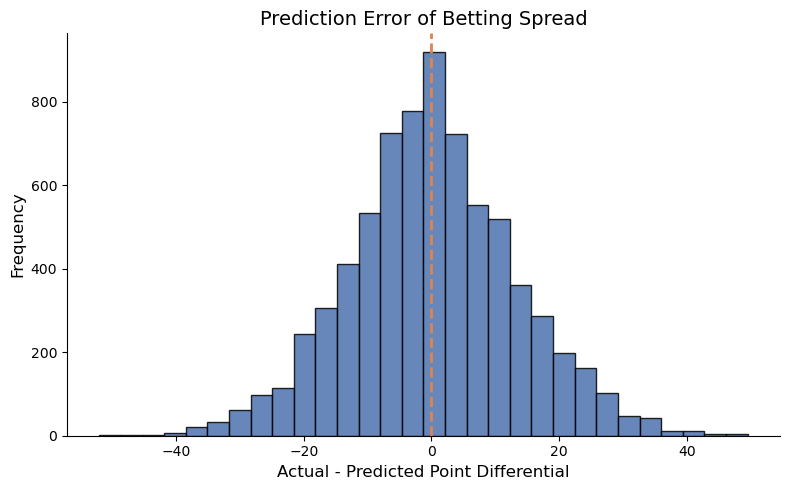

Mean error: 0.09
Std dev: 13.2


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["error"], bins=30, color="#4C72B0", edgecolor="black", alpha=0.85)

plt.axvline(0, linestyle="--", linewidth=2, color="#DD8452")
plt.title("Prediction Error of Betting Spread", fontsize=14)
plt.xlabel("Actual - Predicted Point Differential", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

mean_error = df["error"].mean()
std_error = df["error"].std()

print("Mean error:", round(mean_error, 2))
print("Std dev:", round(std_error, 2))

logging.info("Bias visualization completed")

## Results

The distribution of prediction error is centered close to zero, indicating that betting spreads are approximately unbiased on average. However, the wide spread of values suggests significant variability in individual game outcomes. This indicates that while betting markets are effective at capturing general expectations, they are not precise predictors of exact score differences.

This pipeline integrates data preparation, feature engineering, predictive modeling, and evaluation to analyze NFL game outcomes. By combining betting market data with game-level features, the pipeline not only predicts game results but also evaluates the reliability of betting spreads. 

Overall, betting spreads provide a strong baseline for predicting game outcomes, but their variability highlights the limits of market-based predictions at the individual game level.